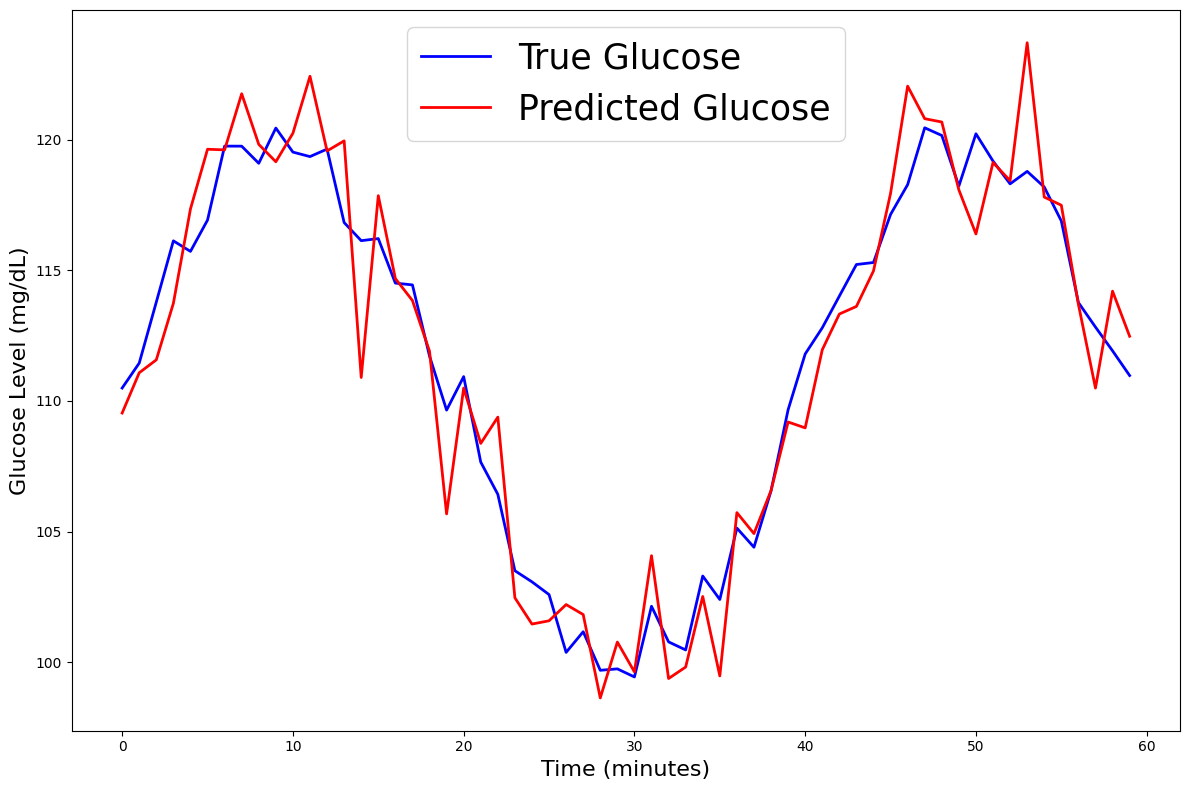

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Time axis: 60 minutes
time = np.arange(60)

# True glucose values: base + slight variation
true_glucose = 110 + np.sin(np.linspace(0, 3 * np.pi, 60)) * 10 + np.random.normal(0, 1, 60)

# Predicted glucose values: close to true values with small error
predicted_glucose = true_glucose + np.random.normal(0, 2, 60)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(time, true_glucose, label='True Glucose', color='blue', linewidth=2)
plt.plot(time, predicted_glucose, label='Predicted Glucose', color='red', linewidth=2)

# Enlarged and centered title and labels
plt.xlabel('Time (minutes)', fontsize=16)
plt.ylabel('Glucose Level (mg/dL)', fontsize=16)

# Larger legend
plt.legend(fontsize=25, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=1)

# Grid and layout
plt.tight_layout()

# Show plot
plt.show()

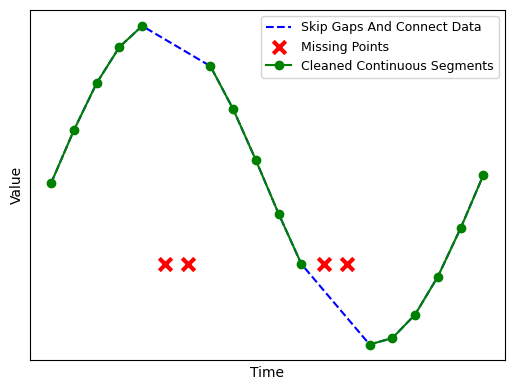

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create sample blood glucose data (with missing values)
time = np.arange(0, 20)
glucose = np.sin(time/3) + 5
glucose[[5, 6, 12, 13]] = np.nan  # Simulate missing points

# Use pandas for linear interpolation to "connect" the gaps
s = pd.Series(glucose)
interpolated_glucose = s.interpolate(method='linear')

# --- Create a plot and overlay all elements ---
fig, ax = plt.subplots(figsize=(5.25, 4))

# Set background to transparent
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


# 1. Plot the interpolated connecting line (blue dashed)
ax.plot(time, interpolated_glucose, "--", color="blue", label="Skip Gaps And Connect Data")

# 2. Mark the original missing points
missing_idx = np.where(np.isnan(glucose))[0]
# ax.scatter(time[missing_idx], interpolated_glucose[missing_idx],  marker="x", c="red", s=80, linewidths=3, label="Missing Points")
# Define a custom y-axis position to display all the 'x' markers
y_for_markers = 4.5 # You can change this value to any desired height
ax.scatter(time[missing_idx], [y_for_markers]*len(missing_idx),  marker="x", c="red", s=80, linewidths=3, label="Missing Points")
# 3. Plot the cleaned, actual data segments (green solid line)
# Find the start and end points of continuous segments
mask = ~np.isnan(glucose)
starts = np.where(np.diff(np.r_[0, mask, 0]) == 1)[0]
ends = np.where(np.diff(np.r_[0, mask, 0]) == -1)[0]

# Loop to plot each continuous segment
for i, (start, end) in enumerate(zip(starts, ends)):
    label = "Cleaned Continuous Segments" if i == 0 else ""
    ax.plot(time[start:end], glucose[start:end], "-o", color="green", label=label)

# --- Configure the plot ---
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(fontsize=9)
ax.set_yticklabels([])  # Do not display y-axis values
ax.set_xticklabels([])  # Do not display x-axis values
plt.yticks([]) 
plt.xticks([]) 
plt.tight_layout()
plt.show()

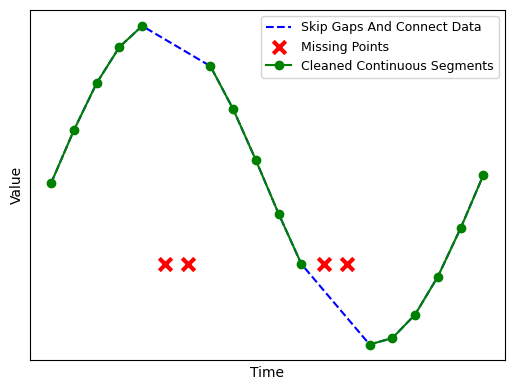

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create sample blood glucose data (with missing values)
time = np.arange(0, 20)
glucose = np.sin(time/3) + 5
glucose[[5, 6, 12, 13]] = np.nan  # Simulate missing points

# Use pandas for linear interpolation to "connect" the gaps
s = pd.Series(glucose)
interpolated_glucose = s.interpolate(method='linear')

# --- Create a plot and overlay all elements ---
fig, ax = plt.subplots(figsize=(5.25, 4))

# Set background to transparent
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


# 1. Plot the interpolated connecting line (blue dashed)
ax.plot(time, interpolated_glucose, "--", color="blue", label="Skip Gaps And Connect Data")

# 2. Mark the original missing points
missing_idx = np.where(np.isnan(glucose))[0]
# ax.scatter(time[missing_idx], interpolated_glucose[missing_idx],  marker="x", c="red", s=80, linewidths=3, label="Missing Points")
# Define a custom y-axis position to display all the 'x' markers
y_for_markers = 4.5 # You can change this value to any desired height
ax.scatter(time[missing_idx], [y_for_markers]*len(missing_idx),  marker="x", c="red", s=80, linewidths=3, label="Missing Points")
# 3. Plot the cleaned, actual data segments (green solid line)
# Find the start and end points of continuous segments
mask = ~np.isnan(glucose)
starts = np.where(np.diff(np.r_[0, mask, 0]) == 1)[0]
ends = np.where(np.diff(np.r_[0, mask, 0]) == -1)[0]

# Loop to plot each continuous segment
for i, (start, end) in enumerate(zip(starts, ends)):
    label = "Cleaned Continuous Segments" if i == 0 else ""
    ax.plot(time[start:end], glucose[start:end], "-o", color="green", label=label)

# --- Configure the plot ---
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(fontsize=9)
ax.set_yticklabels([])  # Do not display y-axis values
ax.set_xticklabels([])  # Do not display x-axis values
plt.yticks([]) 
plt.xticks([]) 
plt.tight_layout()
plt.show()

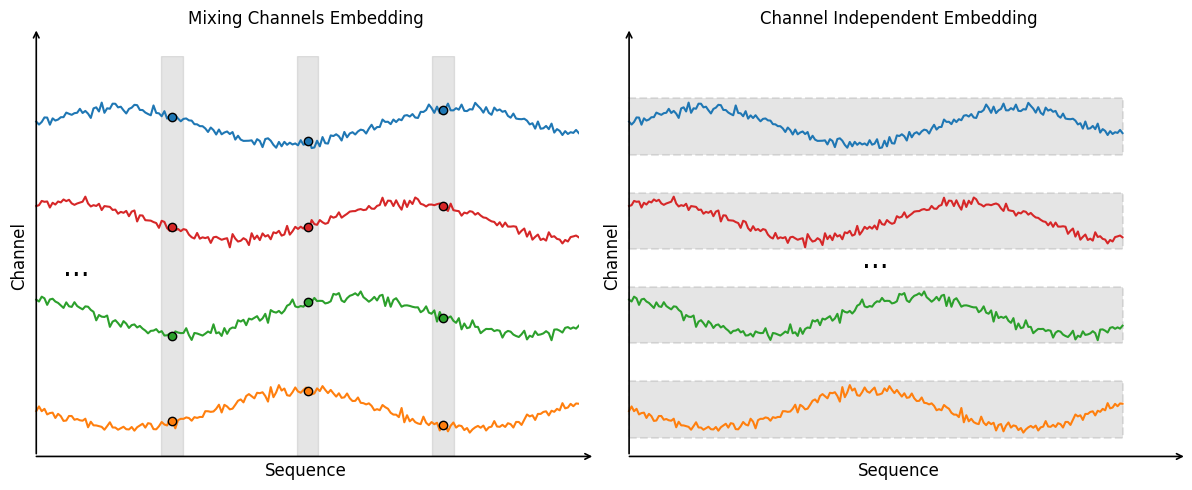

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def _stylize_axes_with_arrows(ax, arrow_pad=0.3, arrow_width=1.2):
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    axis_x = max(x_min, 0)
    axis_y = max(y_min, 0)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax.annotate(
        '',
        xy=(x_max + arrow_pad, axis_y),
        xytext=(x_min, axis_y),
        arrowprops=dict(arrowstyle='->', linewidth=arrow_width, color='black'),
        annotation_clip=False
    )
    ax.annotate(
        '',
        xy=(axis_x, y_max + arrow_pad),
        xytext=(axis_x, y_min),
        arrowprops=dict(arrowstyle='->', linewidth=arrow_width, color='black'),
        annotation_clip=False
    )

def plot_temporal_attention(ax):
    """
    Plots the left figure: Temporal attention mechanism.
    """
    np.random.seed(0)
    x = np.linspace(0, 10, 200)
    
    # 1. Generate and plot four wave lines
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
    y_offsets = [3.5, 2.5, 1.5, 0.5]
    lines = []
    for i in range(4):
        y = np.sin(x + i) * 0.2 + y_offsets[i] + np.random.randn(200) * 0.03
        line, = ax.plot(x, y, color=colors[i])
        lines.append((y, line))

    # 2. Draw vertical gray areas and intersection points
    span_points = [2.5, 5, 7.5]
    for sp in span_points:
        ax.axvspan(sp - 0.2, sp + 0.2, color='grey', alpha=0.2, zorder=0)
        for i in range(4):
            y_val = np.interp(sp, x, lines[i][0])
            ax.plot(sp, y_val, 'o', color=lines[i][1].get_color(), markeredgecolor='black', markersize=6)

    # 4. Add ellipsis
    ax.text(0.5, 2.0, '...', fontsize=20, verticalalignment='center')

    # 5. Set up axes
    ax.set_title('Mixing Channels Embedding', fontsize=12, pad=23)
    ax.set_xlabel('Sequence', fontsize=12)
    ax.set_ylabel('Channel', fontsize=12)
    ax.set_xlim(-0.05, 10)
    ax.set_ylim(0, 4.25)
    _stylize_axes_with_arrows(ax)

def plot_channel_attention(ax):
    """
    Plots the right figure: Channel attention mechanism.
    """
    np.random.seed(0)
    x = np.linspace(0, 10, 200)
    
    # 1. Generate and plot four wave lines
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
    y_offsets = [3.5, 2.5, 1.5, 0.5]
    lines = []
    for i in range(4):
        y = np.sin(x + i) * 0.2 + y_offsets[i] + np.random.randn(200) * 0.03
        line, = ax.plot(x, y, color=colors[i])
        lines.append(y)

    # 2. Draw horizontal gray boxes surrounding each line
    for i in range(4):
        rect = patches.Rectangle(
            (0, y_offsets[i] - 0.3), 10, 0.6,
            linewidth=1.5, edgecolor='grey', facecolor='grey',
            linestyle='--', alpha=0.2, zorder=0
        )
        ax.add_patch(rect)

    # 4. Add ellipsis
    ax.text(5, 2.0, '...', fontsize=20, horizontalalignment='center')

    # 5. Set up axes
    ax.set_title('Channel Independent Embedding', fontsize=12, pad=23)
    ax.set_xlabel('Sequence', fontsize=12)
    ax.set_ylabel('Channel', fontsize=12)
    ax.set_xlim(-0.05, 11)
    ax.set_ylim(0, 4.25)
    _stylize_axes_with_arrows(ax)

# --- Create and display the two subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_temporal_attention(ax1)
plot_channel_attention(ax2)

plt.tight_layout()
plt.show()